# No Show Prediction

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Datasets/cleaned_dataset.csv')
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])
print('Shape:', df.shape)
df.head()

Shape: (109593, 34)


,specialty,appointment_time,no_show,place,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,...,age_missing,disability_intellectual,disability_motor,rain_no_rain,rain_weak,rain_moderate,heat_mild,heat_warm,heat_heavy_warm,heat_heavy_cold
0,psychotherapy,17,1,Lake Marvinville,1,9.0,1,0,1,23.18,...,0,1,0,1,0,0,0,1,0,0
1,Unknown,7,0,ITAPEMA,0,11.0,1,0,1,14.31,...,0,1,0,1,0,0,0,0,0,0
2,speech therapy,16,0,ITAJAÍ,1,8.0,1,0,1,21.61,...,0,1,0,1,0,0,0,1,0,0
3,speech therapy,14,1,Sarahside,1,9.0,1,0,1,21.39,...,0,1,0,0,0,1,1,0,0,0
4,physiotherapy,8,0,ITAJAÍ,0,12.0,0,0,0,20.15,...,1,0,1,1,0,0,1,0,0,0


In [22]:
# drop columns not useful for no show prediction

DROP = ['specialty', 'place', 'appointment_date_continuous']
df_model = df.drop(columns=DROP)

X = df_model.drop('no_show', axis=1)
y = df_model['no_show']

print('Features:', X.columns.tolist())
print('Feature count:', len(X.columns))
print('Class distribution:', y.value_counts().to_dict())

Features: ['appointment_time', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'gender_M', 'gender_I', 'age_missing', 'disability_intellectual', 'disability_motor', 'rain_no_rain', 'rain_weak', 'rain_moderate', 'heat_mild', 'heat_warm', 'heat_heavy_warm', 'heat_heavy_cold']
Feature count: 30
Class distribution: {0: 74761, 1: 34832}


In [23]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 87674
Test size: 21919


## Logistic Regression Model

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, roc_curve

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, lr_prob), 4))

              precision    recall  f1-score   support

           0       0.76      0.66      0.70     14952
           1       0.43      0.54      0.48      6967

    accuracy                           0.62     21919
   macro avg       0.59      0.60      0.59     21919
weighted avg       0.65      0.62      0.63     21919

ROC-AUC: 0.6355


## Random Forest Model

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, rf_prob), 4))

              precision    recall  f1-score   support

           0       0.80      0.77      0.78     14952
           1       0.54      0.59      0.56      6967

    accuracy                           0.71     21919
   macro avg       0.67      0.68      0.67     21919
weighted avg       0.72      0.71      0.71     21919

ROC-AUC: 0.753


## LightGBM Model

In [26]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lgb_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, lgb_prob), 4))

              precision    recall  f1-score   support

           0       0.83      0.71      0.77     14952
           1       0.53      0.70      0.60      6967

    accuracy                           0.71     21919
   macro avg       0.68      0.70      0.68     21919
weighted avg       0.74      0.71      0.71     21919

ROC-AUC: 0.763


In [27]:
print('MODEL COMPARISON')

for name, pred, prob in [
    ('Logistic Regression', lr_pred, lr_prob),
    ('Random Forest', rf_pred, rf_prob),
    ('LightGBM', lgb_pred, lgb_prob)
]:
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    print(name)
    print('  F1:', round(f1, 4), '  ROC-AUC:', round(auc, 4))
print()
print('Best model: LightGBM')

MODEL COMPARISON
Logistic Regression
  F1: 0.4782   ROC-AUC: 0.6355
Random Forest
  F1: 0.5614   ROC-AUC: 0.753
LightGBM
  F1: 0.6013   ROC-AUC: 0.763

Best model: LightGBM


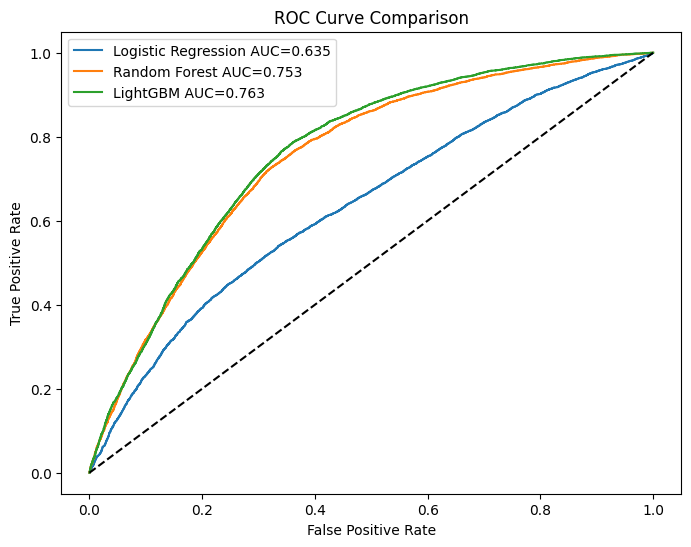

In [ ]:
# ROC curve - model comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for name, prob in [('Logistic Regression', lr_prob), ('Random Forest', rf_prob), ('LightGBM', lgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=name + ' AUC=' + str(round(auc, 3)))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

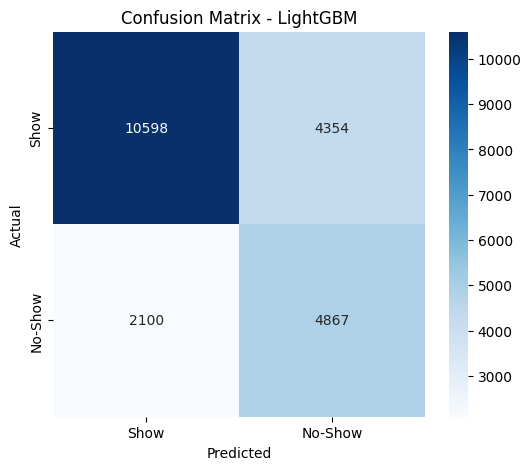

In [29]:
# confusion matrix

cm = confusion_matrix(y_test, lgb_pred)
plt.figure(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Show', 'No-Show'],
            yticklabels=['Show', 'No-Show'])
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

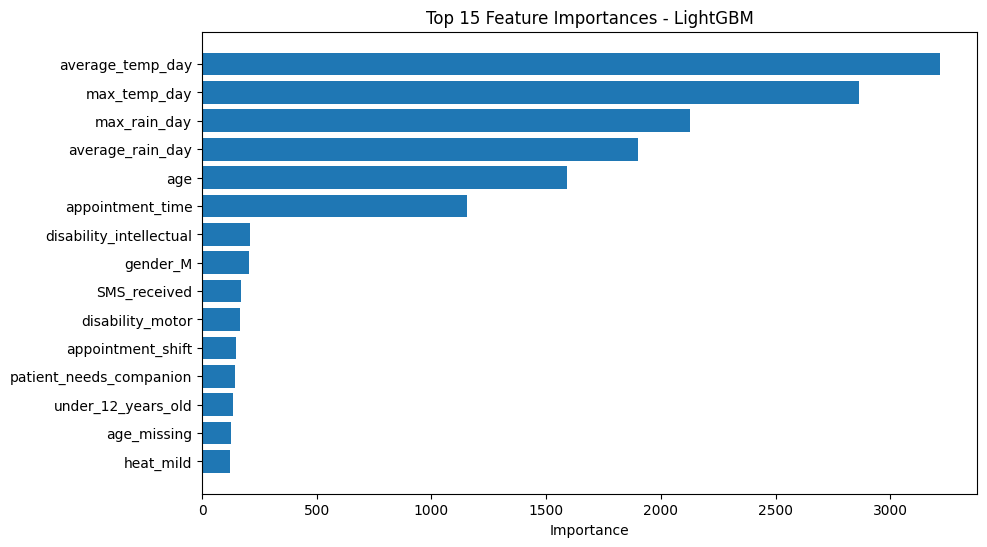

                feature  importance
       average_temp_day        3218
           max_temp_day        2864
           max_rain_day        2128
       average_rain_day        1899
                    age        1589
       appointment_time        1155
disability_intellectual         210
               gender_M         204
           SMS_received         168
       disability_motor         167
      appointment_shift         147
patient_needs_companion         143
     under_12_years_old         134
            age_missing         127
              heat_mild         121


In [30]:
# feature importance

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.title('Top 15 Feature Importances - LightGBM')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importance.to_string(index=False))

In [31]:
import joblib
import os

os.makedirs('model', exist_ok=True)
joblib.dump(lgb_model, 'model/no_show_model.pkl')
joblib.dump(list(X.columns), 'model/no_show_features.pkl')
print('Model saved!')
print('Features saved:', list(X.columns))

Model saved!
Features saved: ['appointment_time', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'gender_M', 'gender_I', 'age_missing', 'disability_intellectual', 'disability_motor', 'rain_no_rain', 'rain_weak', 'rain_moderate', 'heat_mild', 'heat_warm', 'heat_heavy_warm', 'heat_heavy_cold']
